<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/KNN_AdaBoost_Bayes_y_otros_clasificadores_datos_felicidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

El caso de estudio analiza y construye modelos de clasificación con datos relacionados con felicidad de personas o estudiantes de nivel superior a partir de características sociodemográficas de cada uno de ellos.

Los datos se encuentran en el enlace de github.com en el espacio del autor: https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_felicidad_estudiantes_mexico_3000.csv .

Este caso de estudio se puede ver de manera digital el el servicio *google collab* en https://colab.research.google.com/drive/1hTRQ9Cj4hc6T1xOIw4QxQHGTksKsUEjv?usp=sharing .

De igual forma el caso de estudio se encuentra en *github.com* en https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/KNN_AdaBoost_Bayes_y_otros_clasificadores_datos_felicidad.ipynb .


La estructura de los datos se compone de tres mil registos y 13 variables de las cuales estas son las variables independientes:

* *edad* que implica la edad del estudiante (años),
* *salud* es la percepción del estado general de salud en una escala de 1 a 10,
* *sueno* la calidad del sueño en una escala de 1 a 10,                                        
* *estres* almacena el nivel de estrés académico percibido en una escala de 1 a 10,    
* *ingreso* es el nivel de ingreso económico personal o familiar en una escala de 1 a 10,
* *relaciones* la calidad de las relaciones sociales y familiares en una escala de 1 a 10,             
* *recreacion* la frecuencia con la que participa en actividades recreativas, en una escala de 1 a 10,
* *promedio* el promedio académico del estudiante (0–100),
* *actividad_fisica* el nivel de actividad física semanal en una escala de 1 a 10,
* *estudio* son las horas promedio dedicadas al estudio por semana,
* *autoestima* es el nivel de autoestima percibido en una escala de 1 a 10,
* *optimismo* es el nivel de optimismo frente al futuro en una escala de 1 a 10,

La variable dependiente es *felicidad* es categórica y tiene tres valores de acuerdo a nivel de felicidad:

* 0 = Baja felicidad
* 1 = Felicidad media
* 2 = Alta felicidad

El caso de estudio contiene y manda llamar funciones que se encuentra en el enlace de *github.com* en el espacio del autor: **PENDIENTE**




# Objetivo

Construir modelos de clasificación *KNN*, *Ada Boost* y *Bayes* con datos de felicidad de personas para comparar y evaluar la calidad predictiva y de clasificación de estos modelos contra otros modelos de clasificación.

# Descripción

Se sigue la metodología y estructura de los anteriores casos de estudio y que fue descrita en el capítulo tres.

## Cargar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split

from sklearn.svm import LinearSVC # Kernel lineal
from sklearn.svm import SVC # Para SVM
# Para arboles de clasificación y bosques aleatorios
from sklearn.tree import DecisionTreeClassifier # Árbol de clasificación
from sklearn.ensemble import RandomForestClassifier # Bosque aleatorio de clasificación
from sklearn.tree import plot_tree # Visualización del árbol
from sklearn.tree import export_text # Exportar reglas del árbol

from sklearn.linear_model import LogisticRegression # Reg Logistica
from sklearn.utils import resample # Muestras y submuestras

from sklearn.pipeline import Pipeline              #
from sklearn.preprocessing import StandardScaler   # Escalar en caso
from sklearn.neighbors import KNeighborsClassifier # KNN

from sklearn.ensemble import AdaBoostClassifier   # Ada Boost
from sklearn.naive_bayes import GaussianNB        # Bayes


## Cargar funciones


In [2]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20y%20evaluar%20KNN%20ADA%20BOOST%20Y%20BAYES%20entre%20otros%20modelos%20de%20clasificacion.py"
import requests

exec(requests.get(url).text)

## Cargar datos

Se cargan los datos con la función *f_cargar_datos()* y se visulizan los primeros y últimos registros del conjunto de datos y las primeras y últimas cuatro variables.

In [3]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_felicidad_estudiantes_mexico_3000.csv"
datos = f_cargar_datos (url)
f_visualizar_head_tail_reducido(f_redondear(datos))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,28,2,1,5,...,39,2,10,0
1,24,1,1,2,...,39,7,4,0
2,25,10,5,1,...,18,6,2,1
3,19,7,2,6,...,34,9,2,1
4,24,2,9,5,...,9,1,4,1
5,30,5,2,4,...,28,3,6,1
6,...,...,...,...,...,...,...,...,...
7,24,9,10,5,...,21,7,10,2
8,21,10,9,3,...,39,6,10,2
9,23,9,7,1,...,20,9,10,2


## Transformar la variable dependiente felicidad a variable categórica



In [4]:
datos = f_convertir_categorias(datos)

## Estadísticos descriptivos

Se presentan estadísticos descriptivos de las variables independientes.


In [5]:
f_describir_datos(datos)

{'describe':              count       mean        std     min      25%     50%       75%  \
 edad        3000.0    24.0457     3.7646    18.0    21.00    24.0     27.00   
 salud       3000.0     6.5367     3.0065     1.0     4.00     7.0      9.00   
 sueno       3000.0     6.2620     2.9203     1.0     4.00     7.0      9.00   
 estres      3000.0     4.7733     2.9114     1.0     2.00     4.0      7.00   
 ingreso     3000.0  7372.1903  3253.6288  1000.0  4623.75  7870.5  10245.75   
 familia     3000.0     6.3257     2.9321     1.0     4.00     7.0      9.00   
 amigos      3000.0     8.8267     4.6966     0.0     5.00    10.0     13.00   
 recreacion  3000.0    14.8443     7.6522     0.0     9.00    16.0     22.00   
 promedio    3000.0    83.3223    11.9142    60.0    73.00    85.0     94.00   
 estudio     3000.0    24.1993    10.4364     5.0    15.00    25.0     34.00   
 autoestima  3000.0     6.2230     2.9303     1.0     4.00     7.0      9.00   
 optimismo   3000.0     6.32

## Frecuencia de clase dependiente felicidad

Se presenta la frecuencia de la clase y variable dependiente *felicidad*.


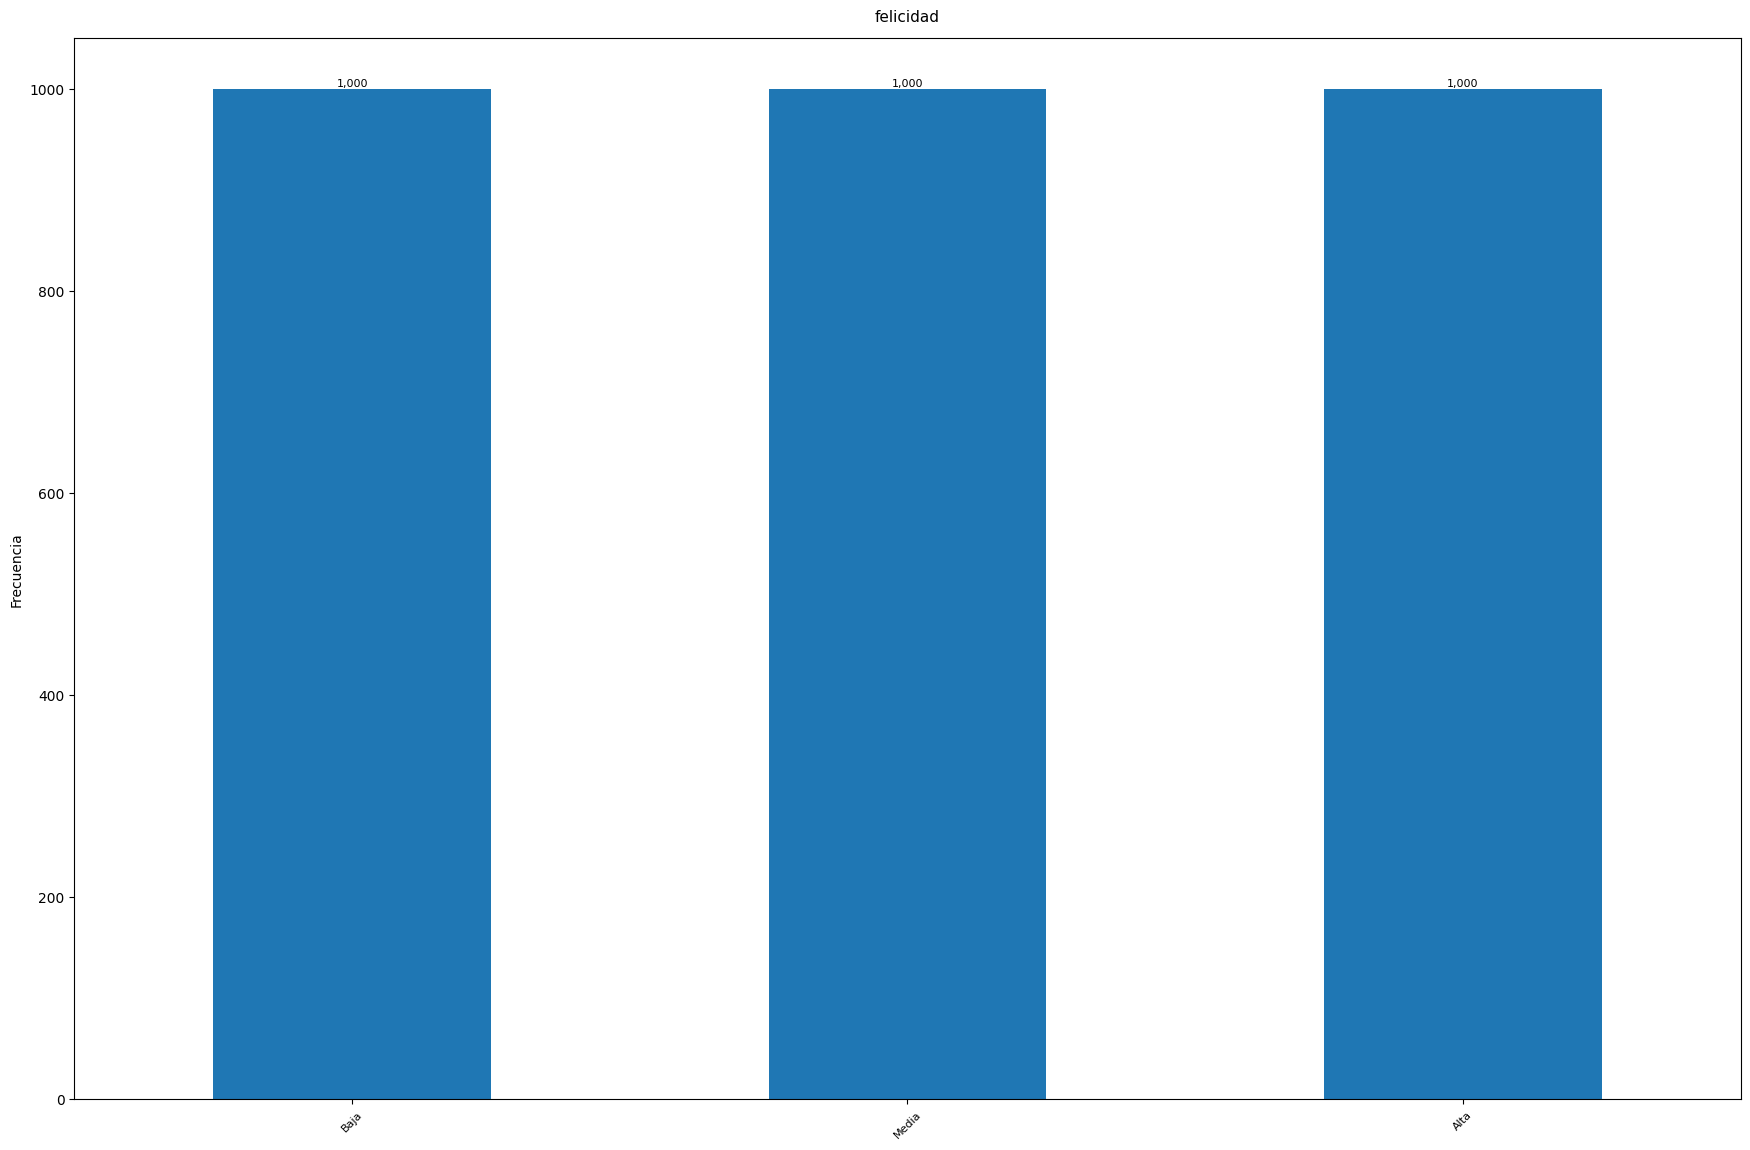

In [6]:
f_frecuencias_clases(datos)

# Desarrollo


## Datos de entrenamiento y datos de validación

In [7]:
particiones = f_particionar_datos(datos)
datos_entrenamiento = particiones["datos_entrenamiento"]
datos_validacion = particiones["datos_validacion"]
f_visualizar_head_tail_reducido(f_redondear(datos_entrenamiento))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,25,9,5,10,...,8,4,6,Baja
1,24,10,7,4,...,40,9,8,Alta
2,23,7,4,9,...,11,9,7,Baja
3,19,9,10,1,...,31,7,8,Alta
4,24,5,2,9,...,9,4,1,Baja
5,24,8,9,8,...,13,2,2,Media
6,...,...,...,...,...,...,...,...,...
7,22,7,5,5,...,11,6,4,Media
8,21,5,10,4,...,5,8,10,Alta
9,25,10,7,1,...,5,10,8,Alta


Datos de validción:


In [8]:
f_visualizar_head_tail_reducido(f_redondear(datos_validacion))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,18,5,8,3,...,21,4,3,Baja
1,22,2,1,3,...,33,8,2,Baja
2,28,9,5,6,...,5,5,9,Media
3,25,10,6,2,...,28,10,2,Alta
4,20,9,8,4,...,27,10,9,Media
5,23,9,10,1,...,18,9,9,Alta
6,...,...,...,...,...,...,...,...,...
7,19,7,1,10,...,13,1,2,Baja
8,21,1,9,4,...,6,7,3,Media
9,21,8,7,8,...,39,5,10,Media


## Estandarización de datos

La función *f_estandarizar_train_transf_valid()*, recibe los datos ya particionados, calcula medias y desviaciones únicamente con la los datos de entrenamiento, estandariza estos y aplica exactamente la misma transformación a los datos de validación y devuelve ambos conjuntos listos para construir modelos de clasificación.


In [9]:
resultado = f_estandarizar_train_transf_valid(
    datos_entrenamiento, datos_validacion, "felicidad")

datos_entrenamiento_std = (resultado["datos_entrenamiento"])

datos_validacion_std = (resultado["datos_validacion"])
f_visualizar_head_tail_reducido(f_redondear(datos_entrenamiento_std))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,0.26,0.81,-0.44,1.79,...,-1.55,-0.76,-0.13,Baja
1,-0.01,1.14,0.25,-0.26,...,1.5,0.95,0.57,Alta
2,-0.28,0.14,-0.78,1.45,...,-1.26,0.95,0.22,Baja
3,-1.36,0.81,1.28,-1.29,...,0.64,0.27,0.57,Alta
4,-0.01,-0.53,-1.47,1.45,...,-1.45,-0.76,-1.86,Baja
5,-0.01,0.47,0.94,1.11,...,-1.07,-1.44,-1.52,Media
6,...,...,...,...,...,...,...,...,...
7,-0.55,0.14,-0.44,0.08,...,-1.26,-0.08,-0.82,Media
8,-0.82,-0.53,1.28,-0.26,...,-1.83,0.61,1.26,Alta
9,0.26,1.14,0.25,-1.29,...,-1.83,1.29,0.57,Alta


In [10]:
f_visualizar_head_tail_reducido(f_redondear(datos_validacion_std))

,edad,salud,sueno,estres,...,estudio,autoestima,optimismo,felicidad
0,-1.63,-0.53,0.59,-0.61,...,-0.31,-0.76,-1.17,Baja
1,-0.55,-1.53,-1.81,-0.61,...,0.83,0.61,-1.52,Baja
2,1.06,0.81,-0.44,0.42,...,-1.83,-0.42,0.92,Media
3,0.26,1.14,-0.09,-0.95,...,0.36,1.29,-1.52,Alta
4,-1.09,0.81,0.59,-0.26,...,0.26,1.29,0.92,Media
5,-0.28,0.81,1.28,-1.29,...,-0.59,0.95,0.92,Alta
6,...,...,...,...,...,...,...,...,...
7,-1.36,0.14,-1.81,1.79,...,-1.07,-1.78,-1.52,Baja
8,-0.82,-1.87,0.94,-0.26,...,-1.74,0.27,-1.17,Media
9,-0.82,0.47,0.25,1.11,...,1.41,-0.42,1.26,Media


Ahora con los datos de entrenamiento estandarizados, el momento de construir todos los modelos de clasificación, *KNN*, *Ada Boost*, *Bayes*, estos se comparan y evalúan contra los modelos de clasificación *SVM* con kernel lineal, polinomial y radial; bosques aleatorios con criterios *Gini* y entropía; árboles de decisión con criterio *Gini* y entropía; Regresión Logística multinomial.  

Todos los modelos se construyen utilizando los datos de entrenamiento estandarizados.

Cada modelo se construye utilizando las funciones correspondientes previamente preparadas para esta tarea.

## Modelo KNN

Se construye modelo de clasificación vecinos cercanos *KNN* llamando la función *f_crear_modelo_KNN()*.

In [11]:
modelo_KNN = f_crear_modelo_KNN(datos_entrenamiento_std, "felicidad")
modelo_KNN


---------------------------------------
Modelo KNN construido correctamente
---------------------------------------
Observaciones : 2100
Variables     : 12
k             : 5
Escalamiento  : False
---------------------------------------



KNeighborsClassifier()

## Modelo Ada Boost

Se crea modelo de clasificación *Ada Boost* llamando la función *f_crear_modelo_Ada_Boost()*.



In [12]:
modelo_Ada_Boost = f_crear_modelo_Ada_Boost(datos_entrenamiento_std, "felicidad")
modelo_Ada_Boost


---------------------------------------
Modelo AdaBoost construido correctamente
---------------------------------------
Observaciones : 2100
Variables     : 12
Clasificadores: 50
Learning Rate : 1.0
Random State  : 123
---------------------------------------



AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=123),
                   random_state=123)

## Modelo clasificador de Bayes

Se construye el modelo clasificador de Bayes utilizando la función *f_crear_modelo_Bayes()*.



In [13]:
modelo_Bayes = f_crear_modelo_Bayes(datos_entrenamiento_std, "felicidad")
modelo_Bayes


---------------------------------------
Modelo Naïve Bayes construido correctamente
---------------------------------------
Observaciones : 2100
Variables     : 12
Clases        : 3
---------------------------------------



GaussianNB()

## Modelo SVM kernel lineal

Para un kernel lineal, *LinearSVC* es la implementación recomendada porque utiliza *LIBLINEAR*, siendo mucho más eficiente que *SVC(kernel="linear")*.

In [14]:
modelo_SVM_lineal = f_crear_modelo_SVM_lineal(datos_entrenamiento_std, "felicidad")
modelo_SVM_lineal


MODELO SVM LINEAL
Kernel              : Lineal
Implementación      : LinearSVC (LIBLINEAR)
Cost (C)            : 0.1
Número de clases    : 3
Iteraciones         : 7



LinearSVC(C=0.1, max_iter=10000, random_state=123)

## Modelo SVM kernel polinomial grado 2


In [15]:
modelo_SVM_poly2 = f_crear_modelo_SVM_polinomial(
    datos_entrenamiento_std,
    "felicidad"
)

modelo_SVM_poly2


MODELO SVM POLINOMIAL
Kernel               : Polinomial
Grado                : 2
Cost (C)             : 0.1
Coef0                : 1
Gamma                : scale
Número de clases     : 3
Vectores de soporte  : 679



SVC(C=0.1, coef0=1, degree=2, kernel='poly', probability=True, random_state=123)

## Modelo SVM kernel polinomial grado 3

In [16]:
modelo_SVM_poly3 = f_crear_modelo_SVM_polinomial(
    datos_entrenamiento_std,
    "felicidad", grado=3
)

modelo_SVM_poly3


MODELO SVM POLINOMIAL
Kernel               : Polinomial
Grado                : 3
Cost (C)             : 0.1
Coef0                : 1
Gamma                : scale
Número de clases     : 3
Vectores de soporte  : 566



SVC(C=0.1, coef0=1, kernel='poly', probability=True, random_state=123)

## Modelo SVM kernel radial

In [17]:
modelo_SVM_radial = f_crear_modelo_SVM_radial(
    datos_entrenamiento_std,
    "felicidad"
)
modelo_SVM_radial


MODELO SVM RADIAL
Kernel               : Radial (RBF)
Cost (C)             : 0.1
Gamma                : scale
Número de clases     : 3
Vectores de soporte  : 1280



SVC(C=0.1, probability=True, random_state=123)

## Modelo Bosques aleatorios Gini

In [18]:
modelo_RF_gini = f_construir_random_forest(datos_entrenamiento_std, "felicidad")
modelo_RF_gini


 RANDOM FOREST
Variable objetivo : felicidad
Número de clases  : 3
Variables         : 12
Árboles           : 500
Criterio          : gini
Observaciones     : 2100

Frecuencias:
Alta: 700
Baja: 701
Media: 699


RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=123)

## Modelo Bosques aleatorios entropía

In [19]:
modelo_RF_entropia = f_construir_random_forest(datos_entrenamiento_std,
                                               "felicidad",  criterion="entropy")
modelo_RF_entropia


 RANDOM FOREST
Variable objetivo : felicidad
Número de clases  : 3
Variables         : 12
Árboles           : 500
Criterio          : entropy
Observaciones     : 2100

Frecuencias:
Alta: 700
Baja: 701
Media: 699


RandomForestClassifier(criterion='entropy', n_estimators=500, n_jobs=-1,
                       random_state=123)

## Modelo árboles de decision criterio Gini



In [20]:
modelo_AC_gini= f_construir_arbol_clasificacion(
    datos_entrenamiento_std,
    "felicidad",
    criterion="gini"
)


 ÁRBOL DE CLASIFICACIÓN
Variable objetivo : felicidad
Número clases     : 3
Variables         : 12
Criterio          : gini
Observaciones     : 2100

Frecuencia de clases
Alta: 700
Baja: 701
Media: 699


## Modelo árboles de decisión criterio entropía


In [21]:
modelo_AC_entropia = f_construir_arbol_clasificacion(
    datos_entrenamiento_std,
    "felicidad",
    criterion="entropy"
)


 ÁRBOL DE CLASIFICACIÓN
Variable objetivo : felicidad
Número clases     : 3
Variables         : 12
Criterio          : entropy
Observaciones     : 2100

Frecuencia de clases
Alta: 700
Baja: 701
Media: 699


## Modelos regresión logística multinomial

In [22]:
modelo_RLM = f_crear_modelo_regresion_logistica(
    datos_entrenamiento_std,
    "felicidad",
    tipo="multinomial")


 REGRESIÓN LOGÍSTICA 
Tipo               : multinomial
Balanceo           : ninguno
Variable objetivo  : felicidad
Número de clases   : 3

Frecuencias originales:
{'Baja': 701, 'Alta': 700, 'Media': 699}

Frecuencias entrenamiento:
{'Baja': 701, 'Alta': 700, 'Media': 699}

Observaciones usadas: 2100


## Evaluación de modelos

Se evalúan todos los modelos de clasificación construidos usando los datos de validación estandarizados; se construye la matriz de confusión de las predicciones de cada modelos y se extraen los estadísticos que se presentan resumidos en modo consola.




In [23]:
evaluacion = f_evaluacion(
    modelos=[modelo_KNN, modelo_Ada_Boost, modelo_Bayes,
             modelo_SVM_lineal, modelo_SVM_poly2,
             modelo_SVM_poly3, modelo_SVM_radial,
        modelo_AC_gini, modelo_AC_entropia,
             modelo_RF_gini, modelo_RF_entropia, modelo_RLM],
    datos_validacion=[datos_validacion_std, datos_validacion_std, datos_validacion_std,
                      datos_validacion_std, datos_validacion_std,
        datos_validacion_std, datos_validacion_std,
        datos_validacion_std, datos_validacion_std,
        datos_validacion_std, datos_validacion_std,
        datos_validacion_std],
    variable_dependiente = "felicidad",
    nombres_modelos=["KNN", "Ada Boost", "Bayes",
                     "SVM Lineal", "SVM Poly2",
                     "SVM Poly3", "SVM Radial",
                     "Arboles Gini", "Arboles entropía",
        "Bosques aleatorios Gini", "Bosques aleatorios entropía",
        "Regresión Logística"]
)

evaluacion

,Modelo,Accuracy,Kappa,Precision,Recall,Sensitivity,Specificity,F1,Balanced_Accuracy,Balanceo
0,KNN,0.8733,0.8100,0.8735,0.8735,0.8735,0.9367,0.8714,0.9051,NaN
1,Ada Boost,0.7344,0.6015,0.8195,0.7343,0.7343,0.8670,0.7372,0.8007,NaN
2,Bayes,0.9600,0.9400,0.9607,0.9601,0.9601,0.9800,0.9599,0.9700,NaN
3,SVM Lineal,0.9478,0.9217,0.9539,0.9480,0.9480,0.9739,0.9473,0.9609,NaN
4,SVM Poly2,0.9822,0.9733,0.9827,0.9823,0.9823,0.9911,0.9822,0.9867,NaN
5,SVM Poly3,0.9756,0.9633,0.9758,0.9756,0.9756,0.9878,0.9755,0.9817,NaN
6,SVM Radial,0.9667,0.9500,0.9678,0.9667,0.9667,0.9834,0.9665,0.9750,NaN
7,Arboles Gini,0.7511,0.6267,0.7501,0.7512,0.7512,0.8755,0.7506,0.8134,NaN
8,Arboles entropía,0.7678,0.6517,0.7737,0.7679,0.7679,0.8839,0.7703,0.8259,NaN
9,Bosques aleatorios Gini,0.9300,0.8950,0.9300,0.9301,0.9301,0.9650,0.9298,0.9475,NaN


# Interpretación del caso

El caso de estudio cumple con el objetivo planteado de construir comparar y evaluar modelos de clasificación.

Los datos que se utilizaron fueron de un contexto de felicidad de estudiantes con ciertas características socio demográficas y/o académicas.

Se presentó la descripción estadística de los datos con valores similares a los presentados en *R*, las variables independientes fueron todas de tipo continuo y la variable dependiente felicidad es categórica.

Se hicieron las particiones con el *70%* de los datos para entrenamiento y *30%* para validación.

Se estandarizaron los datos de entrenamiento y con los mismos valores de media y desviación estándar, se normalizaron también los datos de validación cumpliendo con las criterios formales para escalar y/o estandarizar datos de entrenamiento y validación.

Se construyeron los modelos de clasificación *KNN*, *Ada Boost*, clasificador de *Bayes* como esencia de este caso de estudio y se compararon y evaluaron entre ellos mismos así como contra otros modelos como *SVM* con *kernel* lineal polinomial y radial; bosques aleatorios con criterios Gini y entropía; árboles de decisión también con criterios Gini y entropía además; el modelo de regresión logística multinomial.

De acuerdo a los resultados de la evaluación de calidad predictiva y de clasificación de todos los modelos, los modelos de *SVM* presentaron adecuada calidad predictiva seguidos del modelo clasificador de *Bayes*, sin embargo, para estos datos el modelo de regresión logística multinomial fue el mejor evaluado en comparación a todos los modelos de clasificación.

Los resultados obtenidos, fueron similares a los encontrados en el caso de estudio con *R* con estos mismos datos.
